<a href="https://colab.research.google.com/github/Murcha1990/ML_AI24/blob/main/Hometasks/Pro/ML_AI24_HT7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 7: Fraud Detection Competition**

Добро пожаловать на финальное домашнее задание курса! Домашнее задание направлено на систематизацию всех знаний, полученных в процессе учебы.

В нём Вы потренируетесь применять навыки построения пайплайнов машинного обучения, приобретенные в курсе от точки разведочного анализа данных до построения и валидации моделей машинного обучения.

## **Задача**
**Вы будете решать задачу определения фрода:**

https://www.kaggle.com/competitions/fraud-detection-24

**Вам нужно будет:**
- в jupyter notebook провести исследование данных;
- в нём же построить модели и оценить их качество;
- отправить посылку на Kaggle.

Более подробное описание шагов - в ноутбуке ниже.

## **Оценивание и баллы**
- В EDA и во всей работе будут оцениваться полнота и **выводы**;
- При обучении моделей старайтесь обоснованно подходить к их выбору, избегая простого перебора;

**Максимальный балл** - 10 (+ бонусы за Kaggle, см. ниже).


Мягкий дедлайн (окончание соревнования на Kaggle): **15 марта 23:59**


# **Базовое решение и пример формирования файла под submission**


In [5]:
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [37]:
!pip install phik -q


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
import phik
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

pd.set_option('display.max_columns', None)

In [2]:
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')
test_transaction = pd.read_csv('test_transaction.csv')
test_identity = pd.read_csv('test_identity.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [ ]:
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

In [72]:
df_train

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.500,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.000,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.000,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.000,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.000,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417554,3404554,0,10540759,335.000,W,2538,476.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
417555,3404555,0,10540766,160.500,W,6019,583.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
417556,3404556,0,10540775,230.079,C,5059,138.0,200.0,visa,226.0,...,chrome 65.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,SM-A320FL Build/NRD90M
417557,3404557,0,10540789,105.000,W,6697,111.0,150.0,visa,195.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [99]:
df_train.drop(['TransactionID'], axis=1, inplace=True)
df_test.drop(['TransactionID'], axis=1, inplace=True)
df_train.shape, df_test.shape

((417559, 433), (172981, 432))

In [100]:
object_cols = []
num_cols = []
for col in tqdm(df_train.columns.drop('isFraud')):
    if df_train[col].dtype == 'O':
      object_cols.append(col)
    else:
       num_cols.append(col)
print(len(object_cols), len(num_cols))

100%|██████████| 432/432 [00:00<00:00, 70997.98it/s]

31 401


In [ ]:
X = df_train.drop('isFraud', axis=1)
X = X.fillna('')
y = df_train['isFraud'].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

cb = CatBoostClassifier(iterations=3)
cb.fit(X_train, y_train, object_cols, )

Learning rate set to 0.5
0:	learn: 0.2104788	total: 137ms	remaining: 273ms
1:	learn: 0.1292761	total: 250ms	remaining: 125ms
2:	learn: 0.1146007	total: 397ms	remaining: 0us


In [ ]:
y_preds = cb.predict(X_val)

print(classification_report(y_val, y_preds))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98    100689
           1       0.83      0.19      0.31      3701

    accuracy                           0.97    104390
   macro avg       0.90      0.60      0.65    104390
weighted avg       0.97      0.97      0.96    104390



In [ ]:
y_preds_proba = cb.predict_proba(X_val)
roc_auc_score(y_val, y_preds_proba[:, 0])

0.17117304946438627

In [104]:
y_val.sum()

3701

In [105]:
y_preds.sum()

859

# FeatureSelection

In [60]:
ph.iloc[0].describe()

count    432.000000
mean       0.110666
std        0.119592
min        0.000000
25%        0.028881
50%        0.074399
75%        0.158530
max        1.000000
Name: isFraud, dtype: float64

In [66]:
len(ph.iloc[0][ph.iloc[0] > 0.05].index)

267

In [108]:
selected_cols=ph.iloc[0][ph.iloc[0] > 0.05].index
df2 = df_train[selected_cols]

In [ ]:
list(set(object_cols).intersection(selected_cols))

['id_30',
 'DeviceType',
 'M5',
 'id_34',
 'id_35',
 'id_38',
 'DeviceInfo',
 'M2',
 'id_29',
 'id_36',
 'P_emaildomain',
 'id_16',
 'id_28',
 'M9',
 'R_emaildomain',
 'ProductCD',
 'id_15',
 'M4',
 'M3',
 'card6',
 'id_33',
 'id_31']

In [116]:
X = df2.drop('isFraud', axis=1)
X = X.fillna('')
y = df2['isFraud'].values

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

cb = CatBoostClassifier(iterations=3)
cb.fit(X_train, y_train, list(set(object_cols).intersection(selected_cols)), )

y_preds = cb.predict(X_val)

print(classification_report(y_val, y_preds))

y_preds_proba = cb.predict_proba(X_val)
roc_auc_score(y_val, y_preds_proba[:, 0])

Learning rate set to 0.5
0:	learn: 0.2098251	total: 138ms	remaining: 276ms
1:	learn: 0.1394133	total: 254ms	remaining: 127ms
2:	learn: 0.1235163	total: 413ms	remaining: 0us
              precision    recall  f1-score   support

           0       0.97      1.00      0.98    100689
           1       0.80      0.17      0.28      3701

    accuracy                           0.97    104390
   macro avg       0.89      0.58      0.63    104390
weighted avg       0.96      0.97      0.96    104390



0.22392643757732678

Фk сократил количество признаков до 267 и при этом показал результат лучше.

In [ ]:
from sklearn.preprocessing import LabelEncoder

outliers_fraction=df_train['isFraud'].sum()/df_train.shape[0]
random_state=1

classifiers = {'Angle-based Outlier Detector (ABOD)': ABOD(
    contamination=outliers_fraction),
    'Cluster-based Local Outlier Factor': CBLOF(
        contamination=outliers_fraction, check_estimator=False,
        random_state=random_state),
    'Histogram-base Outlier Detection (HBOS)': HBOS(
        contamination=outliers_fraction),
    'Isolation Forest': IForest(contamination=outliers_fraction,
                                random_state=random_state),
    'Local Outlier Factor (LOF)': LOF(
        contamination=outliers_fraction),
}

for col in tqdm(df_train.columns.drop('isFraud')):
    if df_train[col].dtype == 'O':
        df_train[col] = df_train[col].fillna('unseen_category')
        df_test[col] = df_test[col].fillna('unseen_category')
        
        le = LabelEncoder()
        le.fit(list(df_train[col]) + list(df_test[col]))
        df_train[col] = le.transform(df_train[col])
        df_test[col] = le.transform(df_test[col])
        
        df_train[col] = df_train[col].astype('category')
        df_test[col] = df_test[col].astype('category')

    else:
        df_train[col] = df_train[col].fillna(-1)
        df_test[col] = df_test[col].fillna(-1)

# выделяем фолды
month_length = 3600 * 24 * 30
fold3_idx = df_train[df_train['TransactionDT'].min() + 3 * month_length <= df_train['TransactionDT']].index

# выделяем идентификационный и временной признаки
df_train.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)

X_train = df_train.drop(fold3_idx, axis=0)
y_train = X_train['isFraud'].values
X_val = df_train.iloc[fold3_idx]
y_val = X_val['isFraud'].values
X_train = X_train.drop('isFraud', axis=1)
X_val = X_val.drop('isFraud', axis=1)

for clf_name, clf in classifiers.items():
    #обучите алгоритм на X_train_norm
    clf.fit(X_train)
    #test_scores = сделайте предсказание (decision_function) на X_test_norm
    test_scores = clf.decision_function(X_val)
 
    #вычислите roc_auc_score и precision_n_scores для тестовых данных (y_test, test_scores)
    roc = round(roc_auc_score(y_val, np.nan_to_num(test_scores)), ndigits=4)
    prn = round(precision_n_scores(y_val, test_scores), ndigits=4)

    print('{clf_name} ROC:{roc}, precision @ rank n:{prn}, '
          'execution'.format(
        clf_name=clf_name, roc=roc, prn=prn)
    )


# LightGBM

In [117]:
import lightgbm

Повторим FeatureEngeniring из блокнота

In [234]:
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

df_train.drop(['TransactionID'], axis=1, inplace=True)
df_test.drop(['TransactionID'], axis=1, inplace=True)

#прологарифмируем TransactionAmt
df_train['TransactionAmt_log'] = np.log1p(df_train['TransactionAmt'])
df_test['TransactionAmt_log'] = np.log1p(df_test['TransactionAmt'])
#добавление признака "центы" 
df_train['TransactionAmt_Cents'] = np.modf(df_train['TransactionAmt'])[0] * 100
df_test['TransactionAmt_Cents'] = np.modf(df_test['TransactionAmt'])[0] * 100
#домен почты
for col in ['P_emaildomain', 'R_emaildomain']:
    df_train[col + '_suffix'] = df_train[col].map(lambda x: str(x).split('.')[-1])
    df_test[col + '_suffix'] = df_test[col].map(lambda x: str(x).split('.')[-1])
#сщвпадают ли домены плательщика и получателя
df_train['same_emaildomain'] = (df_train['P_emaildomain'] == df_train['R_emaildomain']).astype('uint8')
df_test['same_emaildomain'] = (df_test['P_emaildomain'] == df_test['R_emaildomain']).astype('uint8')
#комбинация card3_card5
df_train['card3_card5'] = df_train['card3'].astype(str) + '_' + df_train['card5'].astype(str)
df_test['card3_card5'] = df_test['card3'].astype(str) + '_' + df_test['card5'].astype(str)

for col in ['card1', 'card2']:
    card_freq = df_train[col].value_counts().to_dict()
    df_train['{}_cnt'.format(col)] = df_train[col].map(card_freq)
    df_test['{}_cnt'.format(col)] = df_test[col].map(card_freq)

new_cols = []
for col in ['card1', 'card2']:
    for agg_type in ['mean', 'median', 'min', 'max']:
        agg_col_name = 'TransactionAmt_{}_{}'.format(col, agg_type)
        card_agg = df_train.groupby(col)['TransactionAmt'].agg([agg_type]).rename({agg_type: agg_col_name}, axis=1)
        df_train = df_train.merge(card_agg, how='left', on=col)
        df_test = df_test.merge(card_agg, how='left', on=col)
        new_cols.append(agg_col_name)
df_train[['TransactionAmt', 'card1'] + new_cols[:4] + ['card2'] + new_cols[4:]].head(10)

,TransactionAmt,card1,TransactionAmt_card1_mean,TransactionAmt_card1_median,TransactionAmt_card1_min,TransactionAmt_card1_max,card2,TransactionAmt_card2_mean,TransactionAmt_card2_median,TransactionAmt_card2_min,TransactionAmt_card2_max
0,68.5,13926,368.656207,150.00,40.00,1343.14,NaN,NaN,NaN,NaN,NaN
1,29.0,2755,243.561654,108.95,10.00,6085.23,404.0,229.298639,108.950,5.000,6085.230
2,59.0,4663,96.343188,59.00,12.50,994.00,490.0,132.193432,77.000,0.424,6450.970
3,50.0,18132,122.751434,67.95,6.00,3190.00,567.0,131.370289,77.950,6.000,3190.000
4,50.0,4497,105.083333,108.95,30.00,200.00,514.0,217.431376,102.000,5.000,31937.391
5,49.0,5937,148.250000,144.00,49.00,317.50,555.0,125.474598,68.094,0.272,3594.950
6,159.0,12308,107.105890,59.00,12.50,2161.00,360.0,98.937829,58.950,5.000,3472.950
7,422.5,12695,143.267797,85.00,7.97,3162.95,490.0,132.193432,77.000,0.424,6450.970
8,15.0,2803,145.065333,77.00,5.00,3511.95,100.0,172.210474,92.000,5.000,5543.230
9,117.0,17399,127.806299,67.95,10.95,2775.00,111.0,148.041209,87.950,3.500,4301.950


In [184]:
pd.set_option("display.max_columns", None)
df_train

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,TransactionAmt_log,TransactionAmt_Cents,P_emaildomain_suffix,R_emaildomain_suffix,same_emaildomain,card3_card5,card1_cnt,card2_cnt,TransactionAmt_card1_mean,TransactionAmt_card1_median,TransactionAmt_card1_min,TransactionAmt_card1_max,TransactionAmt_card2_mean,TransactionAmt_card2_median,TransactionAmt_card2_min,TransactionAmt_card2_max
0,0,86400,68.500,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,117.00000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,117.000000,0.000000,0.0,0.0,0.0,Na

In [ ]:
ph_lgbm = df_train.phik_matrix()
ph_lgbm.iloc[0].describe()

interval columns not set, guessing: ['isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable DeviceInfo is large: 1551. Are you sure this is not an interval variable? Analysis for pairs of variables including DeviceInfo can be slow.
  warnings.warn(
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable V107 for analysis 1. Dropping this column
  warnings.warn(


count    448.000000
mean       0.110097
std        0.118499
min        0.000000
25%        0.028881
50%        0.074399
75%        0.158530
max        1.000000
Name: isFraud, dtype: float64

In [235]:
df3=df_train.copy()
print(df_train.shape[1])
df3=df3[ph_lgbm.iloc[0][ph_lgbm.iloc[0] > 0.1].index]
print(df3.shape[1])

449
176


In [236]:
df_test3 = df_test[df3.columns.drop('isFraud')]

In [ ]:
#Если вдруг столбец TransactionDT был удален из-за низкой корреляции
if not 'TransactionDT' in ph_lgbm.iloc[0][ph_lgbm.iloc[0] > 0.1]:
    df3['TransactionDT']=df_train['TransactionDT']
    df_test3['TransactionDT']=df_test['TransactionDT']

C:\Users\admin\AppData\Local\Temp\ipykernel_9804\3585551080.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test3['TransactionDT']=df_test['TransactionDT']


In [240]:
from sklearn.preprocessing import LabelEncoder

for col in tqdm(list(df3.columns.drop('isFraud'))):
    if df3[col].dtype == 'O':
        df3[col] = df3[col].fillna('unseen_category')
        df_test3[col] = df_test3[col].fillna('unseen_category')
        
        le = LabelEncoder()
        le.fit(list(df3[col]) + list(df_test3[col]))
        df3[col] = le.transform(df3[col])
        df_test3[col] = le.transform(df_test3[col])
        
        df3[col] = df3[col].astype('category')
        df_test3[col] = df_test3[col].astype('category')

    else:
        df3[col] = df3[col].fillna(-1)
        df_test3[col] = df_test3[col].fillna(-1)

# выделяем фолды
month_length = 3600 * 24 * 30
fold0_idx = df3[df3['TransactionDT'] < df3['TransactionDT'].min() + month_length].index
fold1_idx = df3[(df3['TransactionDT'].min() + month_length <= df3['TransactionDT']) & (df3['TransactionDT'] < df3['TransactionDT'].min() + 2 * month_length)].index
fold2_idx = df3[(df3['TransactionDT'].min() + 2 * month_length <= df3['TransactionDT']) & (df3['TransactionDT'] < df3['TransactionDT'].min() + 3 * month_length)].index
fold3_idx = df3[df3['TransactionDT'].min() + 3 * month_length <= df3['TransactionDT']].index
folds_idx = [fold0_idx, fold1_idx, fold2_idx, fold3_idx]

  0%|          | 0/176 [00:00<?, ?it/s]C:\Users\admin\AppData\Local\Temp\ipykernel_9804\3020289014.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test3[col] = df_test3[col].fillna('unseen_category')
C:\Users\admin\AppData\Local\Temp\ipykernel_9804\3020289014.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test3[col] = le.transform(df_test3[col])
C:\Users\admin\AppData\Local\Temp\ipykernel_9804\3020289014.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [241]:
#удаляем временной признак
df3.drop(['TransactionDT'], axis=1, inplace=True)
df_test3.drop(['TransactionDT'], axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_9804\3636413713.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test3.drop(['TransactionDT'], axis=1, inplace=True)


In [242]:
import lightgbm as lgb

params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',
    'n_jobs': -1,
    'n_estimators': 2000,
    'seed': 13,
    'early_stopping_rounds': 200,
}

scores = []

feature_importances = pd.DataFrame()
feature_importances['feature'] = df3.columns.drop('isFraud')

test_preds = []

for i in range(len(folds_idx)):
    X_train = df3.drop(folds_idx[i], axis=0)
    y_train = X_train['isFraud'].values
    X_val = df3.iloc[folds_idx[i]]
    y_val = X_val['isFraud'].values
    X_train = X_train.drop('isFraud', axis=1)
    X_val = X_val.drop('isFraud', axis=1)

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train)
    lgb_model = lgb.train(params, lgb_train, valid_sets=lgb_eval)
    
    feature_importances['fold_{}'.format(i)] = lgb_model.feature_importance()

    y_pred = lgb_model.predict(X_val)
    score_fold = roc_auc_score(y_val, y_pred)
    scores.append(score_fold)
    y_test_pred = lgb_model.predict(df_test3)
    test_preds.append(y_test_pred)

for i in range(len(scores)):
    print('Fold {}, AUC-ROC: {:.5f}'.format(i, scores[i]))
print('CV AUC-ROC: {:.5f}'.format(np.mean(scores)))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 11320, number of negative: 271900
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6586
[LightGBM] [Info] Number of data points in the train set: 283220, number of used features: 175
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039969 -> initscore=-3.178863
[LightGBM] [Info] Start training from score -3.178863
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1027]	valid_0's auc: 0.863149
[LightGBM] [Warning] Categorical features with more bins than the configured max

In [243]:
fold_cols = [col for col in feature_importances.columns if col.startswith('fold_')]
feature_importances['average'] = feature_importances[fold_cols].mean(axis=1)
feature_importances.head()

,feature,fold_0,fold_1,fold_2,fold_3,average
0,ProductCD,41,16,19,26,25.50
1,card3,94,36,27,37,48.50
2,card5,887,263,139,140,357.25
3,card6,55,41,37,36,42.25
4,P_emaildomain,677,366,260,297,400.00


C:\Users\admin\AppData\Local\Temp\ipykernel_9804\175549146.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.sort_values(by='average', ascending=False).head(50), x='average', y='feature', palette="BuGn_r")


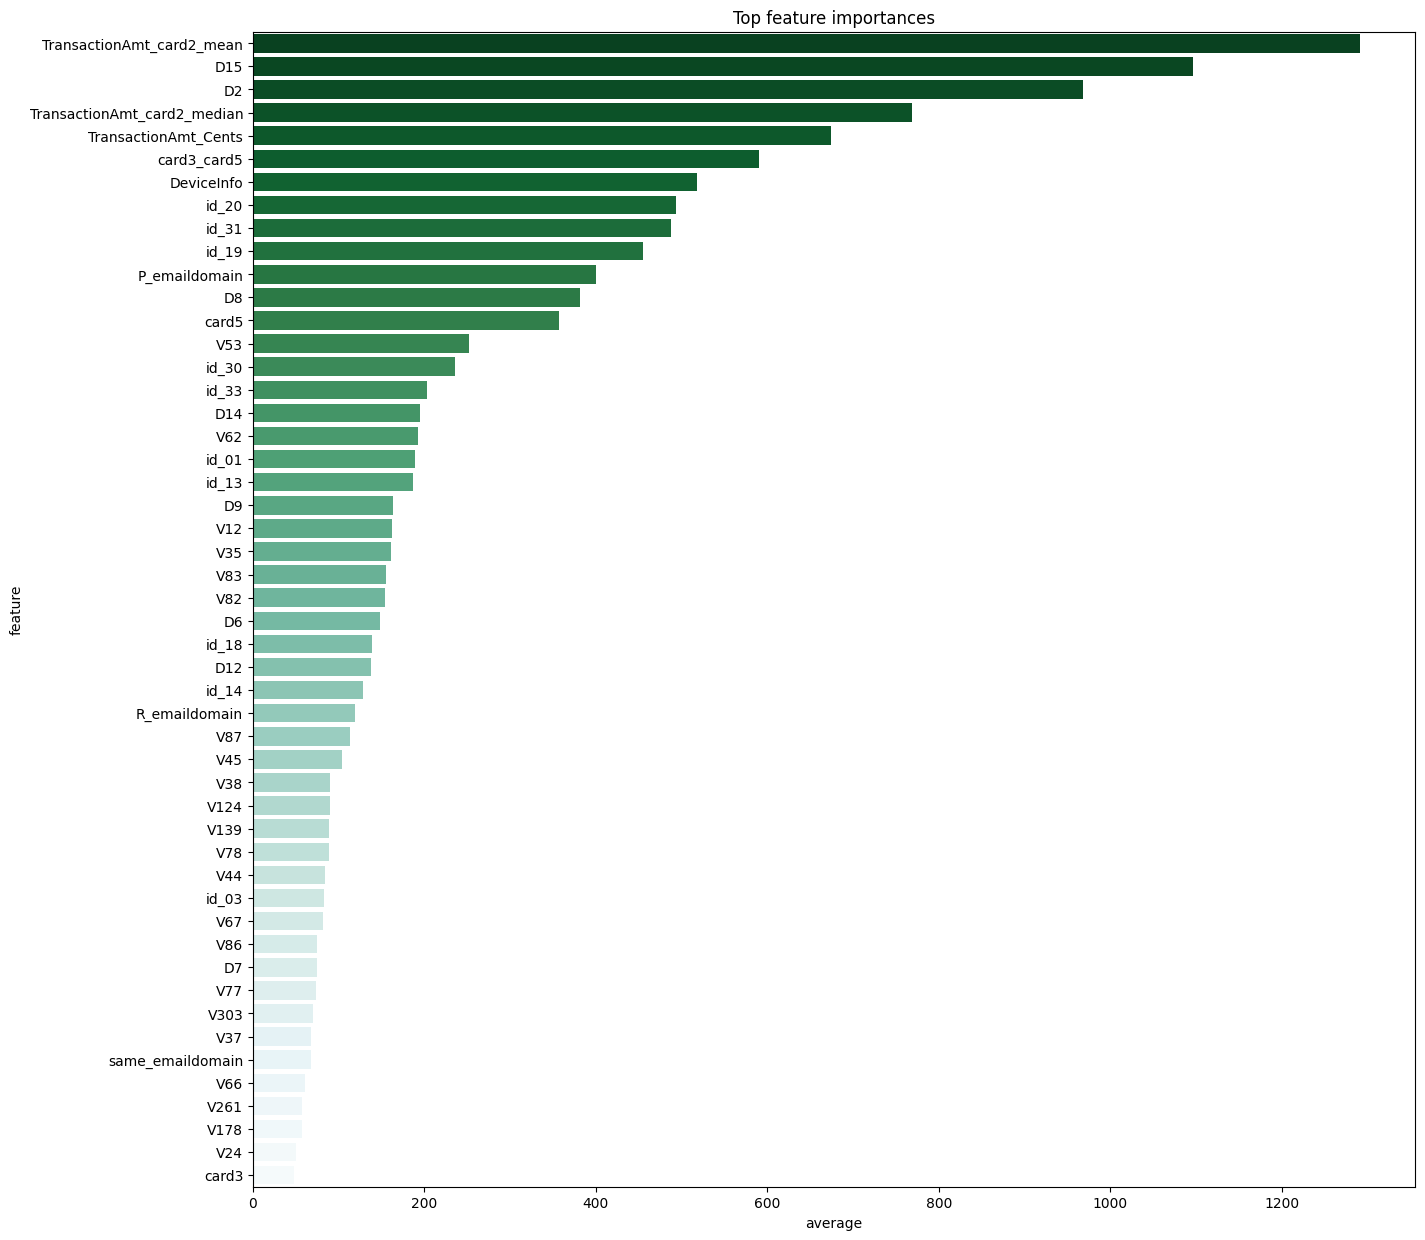

In [244]:
plt.figure(figsize=(15, 15))
sns.barplot(data=feature_importances.sort_values(by='average', ascending=False).head(50), x='average', y='feature', palette="BuGn_r")
plt.title('Top feature importances')
plt.show()

# Predictions

In [245]:
final_pred = np.average(test_preds, axis=0)
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': final_pred})
sub.to_csv('submission_baseline_fe.csv', index=False)

* После feature_engineering и feature_selection количество признаков для обучения снизилось с 446 до 176 (в 2,5 раза, что значительно ускорило процесс обучения). 

* Однако, качество тоже снизилось с 0,91 до 0,87.

* При этом ТОР значимых фичей совершенно поменялся.

In [ ]:
# predictions = cb.predict_proba(df_test.fillna(''))
# sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 0]})
# sub.head()

,TransactionID,isFraud
0,3404559,0.978714
1,3404560,0.935724
2,3404561,0.946864
3,3404562,0.978714
4,3404563,0.970637


### **Примечания:**

**1. Оценка качества и Submission File**
- Ответом является число от 0 до 1, метрикой качества - AUC-ROC.
- Структура Submission File:
 - для каждого значения *TransactionID* в тестовых данных вы должны предсказать **вероятность** для столбца *isFraud*.
 - в файле у вас должно быть две колонки: `TransactionID` и`isFraud`  **для каждой транзакции в датасете**.

**2. Объем данных**

Поскольку набор данных объемный, могут быть проблемы с переполнением памяти в Collab. Для решения проблемы можете использовать функцию из [этого ноутбука](https://colab.research.google.com/drive/18u75eyFGEoyeWJ_MbsLkcPa6gv2tNI8G#scrollTo=V2L1Nl5CTMMl), разобравшись, что она делает с данными.

# **Задание 1 (2 балла)**

Проведите EDA (разведочный анализ данных):
* проанализируйте признаки, их особенности и связь с целевой переменной
* проанализируйте целевую переменную
* оцените степень попарной взаимосвязи признаков, а также связи признаков и целевой переменной
* по результатам исследований сделайте необходимую обработку данных (удаление дублей, работа с пропусками, с категориальными столбцами (если они есть), работа с аномалиями, другие преобразования признаков)

Важно, что EDA всегда сопровождается выводами - не забудьте об этом.

In [ ]:
# ваш EDA здесь
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')

pd.set_option('display.expand_frame_repr', False)
df_train.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,"417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","410,996.000000","416,738.000000","414,578.000000","369,586.000000","369,586.000000","159,468.000000","29,286.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,559.000000","417,285.000000","209,370.000000","221,105.000000","294,503.000000","191,724.000000","53,060.000000","26,946.000000","56,554.000000","56,554.000000","356,071.000000","190,758.000000","47,757.000000","44,466.000000","45,340.000000","348,923.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","190,758.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","356,043.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","294,474.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","354,671.000000","348,906.000000","348,906.000000","348,906.000000","348,906.000000","348,906.000000","348,906.000000","348,906.000000","348,

In [34]:
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

#удалим малоинформативные столбцы
print(df_train.shape[1])

df_train.drop(['TransactionID'], axis=1, inplace=True)
df_test.drop(['TransactionID'], axis=1, inplace=True)

for col in df_train.columns:
    #удалим признаки, у которых количество уникальных значений 1
    if df_train[col].nunique()<=1:
        df_train.drop(columns=[col], inplace=True)
        df_test.drop(columns=[col], inplace=True)
        continue
    #удалим признаки, где количество пропусков больше 85%
    if df_train[col].dtype != 'O':
        if np.isnan(df_train[col]).sum() >= 0.85*df_train.shape[0]:
            df_train.drop(columns=[col], inplace=True)
            df_test.drop(columns=[col], inplace=True)
print(df_train.shape[1])

434
411


<Axes: xlabel='isFraud', ylabel='Count'>

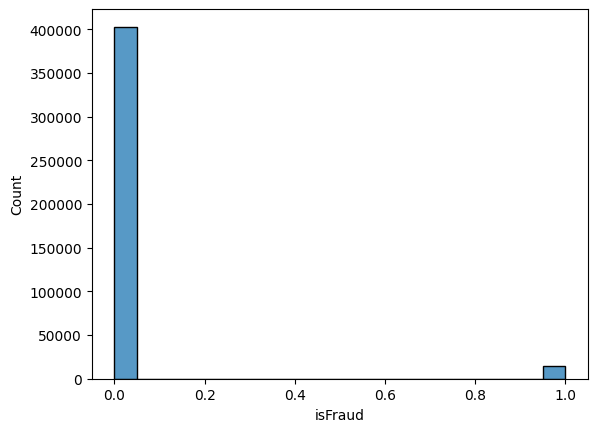

In [ ]:
#сильный дисбаланс
sns.histplot(df_train['isFraud'])

In [ ]:
#посмотрим на долю фрода по некоторым аггрегациям: например * по продукту С все операции с кредитными картами american express являются фродом
#                                                           * по продукту H 80% операций с дебетовыми картами discover являются фродом
#также по другим агрегациям есть довольно высокая доля фрода ~0,15 (продукт С - кредитки visa и master card)

df_train.groupby(['ProductCD' ,'card4', 'card6'])['isFraud'].agg([
    ('Count', 'count'),
    ('Sum', 'sum'),
    ('Ratio', lambda x: x.sum() / x.count())
])

Count   Sum    Ratio
ProductCD card4            card6                                 
C         american express credit                2     2 1.000000
          mastercard       credit             8877  1393 0.156922
                           debit             11308   793 0.070127
          visa             charge card          12     0 0.000000
                           credit            11701  1961 0.167593
                           debit             18499  1497 0.080923
H         american express credit             1272    73 0.057390
                           debit                41     1 0.024390
          discover         credit              535    31 0.057944
                           debit                 5     4 0.800000
          mastercard       credit             3922   214 0.054564
                           debit              2856   125 0.043768
          visa             credit             9452   415 0.043906
                           debit             10125   409 0.040395
R         american express charge card           3     0 0.000000
                           credit             4924    76 0.015435
                           debit                49     3 0.061224
          discover         credit              901    42 0.046615
                           debit                11     0 0.000000
          mastercard       credit             4058   217 0.053475
                           debit              1992    68 0.034137
          visa             credit            11362   460 0.040486
                           debit              6999   212 0.030290
S         american express credit              452    34 0.075221
                           debit                17     0 0.000000
          discover         credit              441    36 0.081633
          mastercard       credit              890    72 0.080899
                           debit               904    44 0.048673
          visa             credit             1986    74 0.037261
                           debit              2577   184 0.071401
W         discover         credit             2664   197 0.073949
                           debit               252     8 0.031746
          mastercard       credit            18407   773 0.041995
                           debit             79159  1018 0.012860
                           debit or credit      30     0 0.000000
          visa             credit            28286  1212 0.042848
                           debit            171754  3047 0.017740

In [ ]:
#для оценки попарной корреляции и корреляции таргета с признаками, построим матрицу Фk

ph = df_train.phik_matrix()
ph

interval columns not set, guessing: ['isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103'

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable DeviceInfo is large: 1551. Are you sure this is not an interval variable? Analysis for pairs of variables including DeviceInfo can be slow.
  warnings.warn(


,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D10,D11,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_19,id_20,id_23,id_27,id_28,id_29,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
isFraud,1.000000,0.054611,0.000000,0.131485,0.057356,0.075518,0.211007,0.028197,0.140823,0.151249,0.016960,0.066021,0.005531,0.104895,0.195448,0.026056,0.041061,0.000000,0.032527,0.039046,0.030378,0.033890,0.025780,0.039867,0.032998,0.032367,0.033780,0.046566,0.028888,0.091296,0.128666,0.042341,0.083430,0.069067,0.094085,0.054877,0.106725,0.000000,0.053129,0.062855,0.082613,0.057045,0.036329,0.010274,0.028413,0.052095,0.000000,0.016859,0.059587,0.049162,0.082284,0.006733,0.033568,0.014252,0.039839,0.068866,0.068362,0.130545,0.088921,0.000728,0.228626,0.050339,0.138408,0.138096,0.059526,0.068597,0.225663,0.164701,0.230929,0.204080,0.030918,0.052537,0.006293,0.006328,0.158904,0.152737,0.212816,0.050474,0.165775,0.049417,0.107388,0.064211,0.153710,0.178572,0.195518,0.180591,0.004538,0.182565,0.191467,0.330157,0.373523,0.137135,0.173900,0.165363,0.165834,0.237936,0.218314,0.203253,0.121399,0.086285,0.088904,0.076955,0.154364,0.239171,0.083083,0.110141,0.084745,0.168513,0.200738,0.204551,0.000000,0.120894,0.119888,0.001961,0.156174,0.105156,0.145493,0.224165,0.235588,0.183101,0.064386,0.079643,0.148711,0.166686,0.273330,0.128325,0.156303,0.112714,0.151223,0.215884,0.225163,0.312155,0.337099,0.001548,0.002857,0.162709,0.109280,0.233869,0.252201,0.281181,0.097466,0.050311,0.080583,0.020220,0.013141,0.028120,0.090127,0.053504,0.073836,0.025066,0.036799,0.041182,0.146828,0.105642,0.130276,0.177777,0.151638,0.166041,0.098907,0.072071,0.089322,0.081541,0.058826,0.073308,0.047151,0.030327,0.041850,0.211177,0.151179,0.195798,0.000000,0.011461,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.035311,0.180752,0.252774,0.158406,0.156087,0.091829,0.089074,0.093122,0.215660,0.294580,0.518778,0.580901,0.092667,0.093910,0.062409,0.516625,0.411920,0.540081,0.576710,0.391524,0.472158,0.090405,0.093327,0.031336,0.122222,0.071078,0.062297,0.094010,0.000000,0.176953,0.072099,0.071629,0.249430,0.292879,0.015688,0.026521,0.028372,0.063082,0.182048,0.217703,0.164562,

In [ ]:
#целевая переменная не очень сильно кореллирует с большинством признаков (75% = 0,16)
ph.iloc[0].describe()

count   411.000000
mean      0.110245
std       0.122150
min       0.000000
25%       0.028374
50%       0.071078
75%       0.160806
max       1.000000
Name: isFraud, dtype: float64

In [ ]:
#удалим признаки, у которых попарная корреляция больше 0,9 (сильно зависимые признаки) и при этом корреляция с таргетом ниже, чем у второго признака 
all_features = list(ph['isFraud'].index)
for feature in ph.keys():
    high_correlation_with=ph[feature][ph[feature]>0.9].sort_values(ascending=False).index[1:]
    for pair in high_correlation_with:
        if ph['isFraud'][feature] > ph['isFraud'][pair]:
            try:
                all_features.remove(pair)
            except:
                continue
        else:
            try:
                all_features.remove(feature)
            except:
                continue
len(all_features)

147

In [ ]:
#в данных 1 дубликат, удалим его
print(df_train.shape[0]-df_train.drop_duplicates().shape[0])
df_train.drop_duplicates(inplace=True)
df_train.reset_index().drop(columns=['index'])

1

In [114]:
df_train_raw=df_train.copy()
df_test_raw=df_test.copy()

In [142]:
df_train=df_train_raw
df_test=df_test_raw
df_train.reset_index().drop(columns=['index'])

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D10,D11,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_19,id_20,id_23,id_27,id_28,id_29,id_30,id_31,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,0,86400,68.500000,W,13926,NaN,150.000000,discover,142.000000,credit,315.000000,87.000000,19.000000,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000,1.000000,14.000000,NaN,13.000000,NaN,NaN,13.000000,13.000000,0.000000,T,T,T,M2,F,T,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,117.000000,0.000000,0.000000,0.000000,0.000000,0.000000,117.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [144]:
#оставляем только отобранные по корреляции столбцы
df_train=df_train[all_features]
test_features=all_features[1:]
df_test=df_test[test_features]

#заполняем пропуски и кодируем категориальные признаки
for col in tqdm(df_train.columns.drop('isFraud')):
    if df_train[col].dtype == 'O':
        df_train[col] = df_train[col].fillna('unseen_category')
        df_test[col] = df_test[col].fillna('unseen_category')
        
        le = LabelEncoder()
        le.fit(list(df_train[col]) + list(df_test[col]))
        df_train[col] = le.transform(df_train[col])
        df_test[col] = le.transform(df_test[col])
        
        df_train[col] = df_train[col].astype('category')
        df_test[col] = df_test[col].astype('category')

    else:
        df_train[col] = df_train[col].fillna(-1)
        df_test[col] = df_test[col].fillna(-1)

  0%|          | 0/146 [00:00<?, ?it/s]C:\Users\admin\AppData\Local\Temp\ipykernel_19184\181933002.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train[col] = df_train[col].fillna(-1)
C:\Users\admin\AppData\Local\Temp\ipykernel_19184\181933002.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test[col] = df_test[col].fillna(-1)
C:\Users\admin\AppData\Local\Temp\ipykernel_19184\181933002.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

# **Задание 2 (3 балла)**

Обучите несколько ML-моделей для решения поставленной задачи.
Оцените их качество двумя способами:

1) на кросс-валидации

2) на лидерборде

Подберите число фолдов на кросс-валидации так, чтобы метрики, которые вы видите, были максимально близки на кросс-валидации и на лидерборде.

По результатам экспериментов постройте таблицу:
* в каждой строке таблицы - результаты одной модели
* по столбцам: качество на кросс-валидации, качество на лидерборде, модель с гиперпараметрами
Полученную таблицу вставьте картинкой прямо в ноутбук после ячеек с кодом. Сделайте текстовые выводы.

In [ ]:
# ваши модели здесь

# выделяем фолды для кросс валидации, т.к. данные структурированы во времени (по месяцам)
month_length = 3600 * 24 * 30
fold0_idx = df_train[df_train['TransactionDT'] < df_train['TransactionDT'].min() + month_length].index
fold1_idx = df_train[(df_train['TransactionDT'].min() + month_length <= df_train['TransactionDT']) & (df_train['TransactionDT'] < df_train['TransactionDT'].min() + 2 * month_length)].index
fold2_idx = df_train[(df_train['TransactionDT'].min() + 2 * month_length <= df_train['TransactionDT']) & (df_train['TransactionDT'] < df_train['TransactionDT'].min() + 3 * month_length)].index
fold3_idx = df_train[df_train['TransactionDT'].min() + 3 * month_length <= df_train['TransactionDT']].index
folds_idx = [fold0_idx, fold1_idx, fold2_idx, fold3_idx]

#удаляем временной признак
df_train.drop(['TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionDT'], axis=1, inplace=True)

C:\Users\admin\AppData\Local\Temp\ipykernel_19184\3347674896.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.drop(['TransactionDT'], axis=1, inplace=True)
C:\Users\admin\AppData\Local\Temp\ipykernel_19184\3347674896.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.drop(['TransactionDT'], axis=1, inplace=True)


In [163]:
#lightgbm

params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'metric': 'auc',
    'n_jobs': -1,
    'n_estimators': 1000,
    'seed': 13,
    'early_stopping_rounds': 200,
}

scores = []

feature_importances = pd.DataFrame()
feature_importances['feature'] = df_train.columns.drop('isFraud')

test_preds = []

for i in range(len(folds_idx)):
    print(f'ФОЛД {i}')
    X_train = df_train.drop(folds_idx[i], axis=0)
    y_train = X_train['isFraud'].values
    X_train = X_train.drop('isFraud', axis=1)
    X_val = df_train.loc[folds_idx[i]]
    y_val = X_val['isFraud'].values
    X_val = X_val.drop('isFraud', axis=1)

    lgb_train = lgb.Dataset(X_train, y_train)
    lgb_eval = lgb.Dataset(X_val, y_val, reference=lgb_train)
    lgb_model = lgb.train(params, lgb_train, valid_sets=lgb_eval)
    
    feature_importances['fold_{}'.format(i)] = lgb_model.feature_importance()

    y_pred = lgb_model.predict(X_val)
    score_fold = roc_auc_score(y_val, y_pred)
    scores.append(score_fold)
    y_test_pred = lgb_model.predict(df_test)
    test_preds.append(y_test_pred)

for i in range(len(scores)):
    print('Fold {}, AUC-ROC: {:.5f}'.format(i, scores[i]))
print('CV AUC-ROC: {:.5f}'.format(np.mean(scores)))

ФОЛД 0
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 11320, number of negative: 271899
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9147
[LightGBM] [Info] Number of data points in the train set: 283219, number of used features: 144
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039969 -> initscore=-3.178860
[LightGBM] [Info] Start training from score -3.178860
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[540]	valid_0's auc: 0.898651
ФОЛД 1
[LightGBM] [Warning] Categorical features with more bins than the c

C:\Users\admin\AppData\Local\Temp\ipykernel_19184\186286318.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances.sort_values(by='average', ascending=False).head(50), x='average', y='feature', palette="BuGn_r")


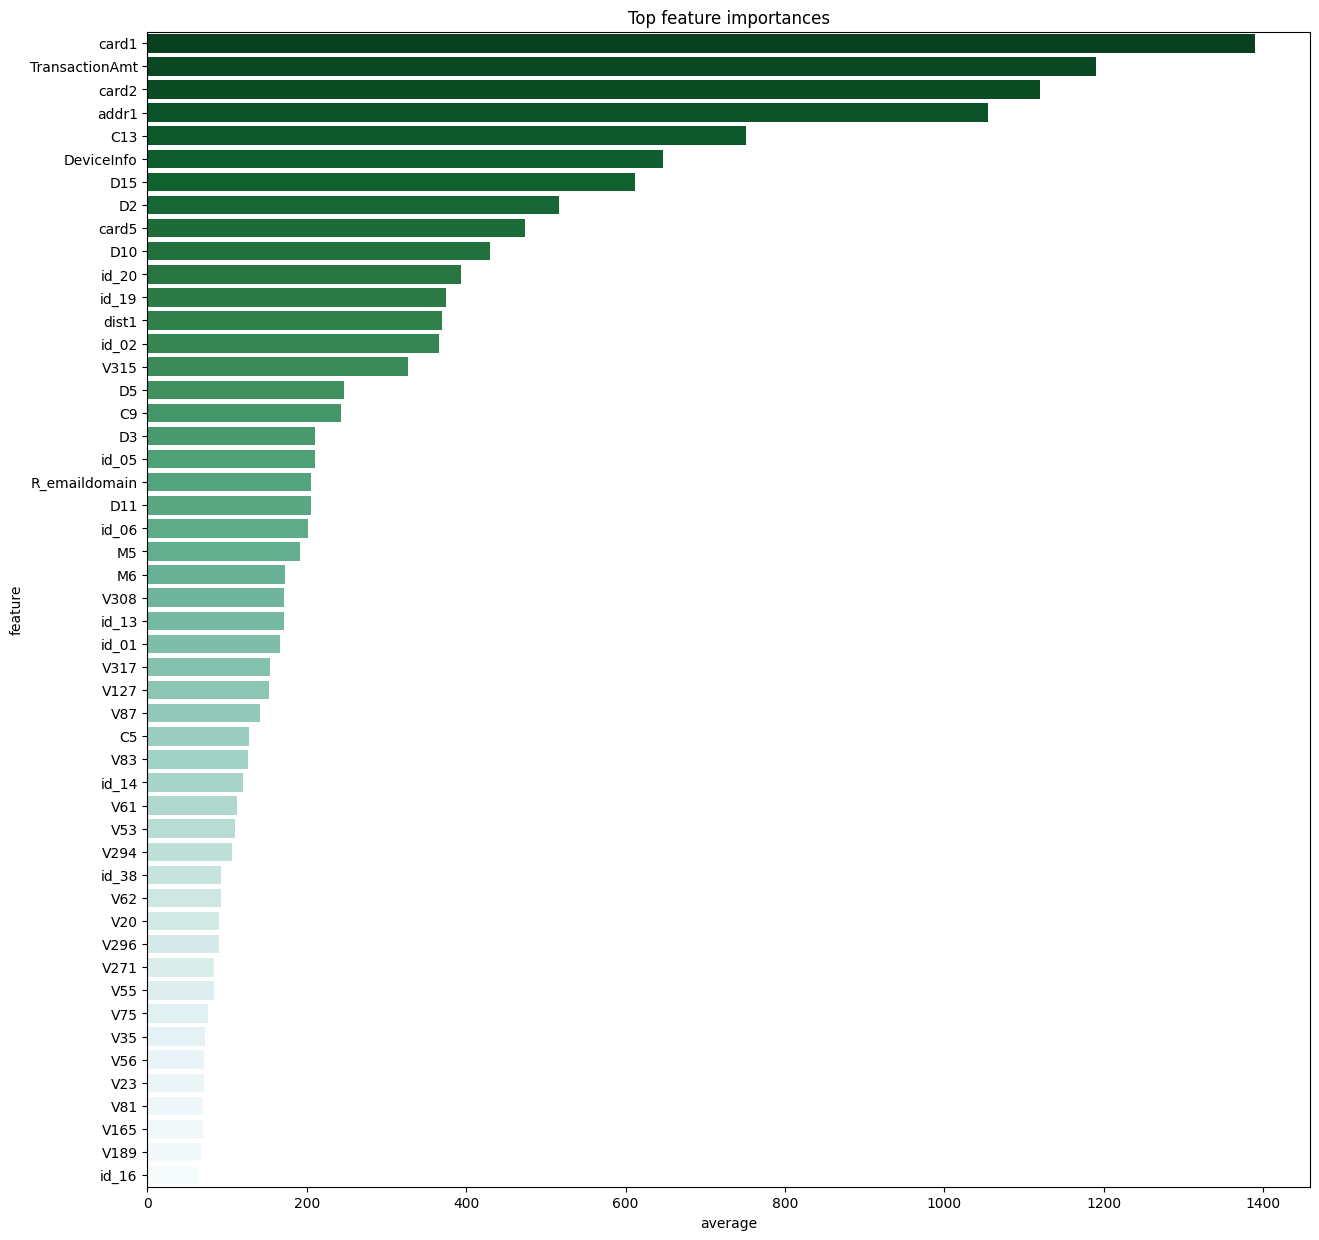

In [167]:
fold_cols = [col for col in feature_importances.columns if col.startswith('fold_')]
feature_importances['average'] = feature_importances[fold_cols].mean(axis=1)
plt.figure(figsize=(15, 15))
sns.barplot(data=feature_importances.sort_values(by='average', ascending=False).head(50), x='average', y='feature', palette="BuGn_r")
plt.title('Top feature importances')
plt.show()

In [158]:
final_pred = np.average(test_preds, axis=0)
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': final_pred})
sub.to_csv('submission_phik+lightgbm.csv', index=False)

In [179]:
#catboost

cb = CatBoostClassifier(iterations=300,
                        learning_rate=1.5,
                        )

scores_cb = []
cat_cols=[col for col in df_train.columns if df_train[col].dtype in ['O', 'category']]

feature_importances_cb = pd.DataFrame()
feature_importances_cb['feature'] = df_train.columns.drop('isFraud')

test_preds = []

for i in range(len(folds_idx)):
    print(f'ФОЛД {i}')
    X_train = df_train.drop(folds_idx[i], axis=0)
    y_train = X_train['isFraud'].values
    X_train = X_train.drop('isFraud', axis=1)
    X_val = df_train.loc[folds_idx[i]]
    y_val = X_val['isFraud'].values
    X_val = X_val.drop('isFraud', axis=1)

    cb_model = cb.fit(X_train, y_train, cat_cols)
    
    feature_importances_cb['fold_{}'.format(i)] = cb_model.get_feature_importance()

    y_pred = cb_model.predict(X_val)
    score_fold = roc_auc_score(y_val, y_pred)
    scores_cb.append(score_fold)
    y_test_pred = cb_model.predict(df_test)
    test_preds.append(y_test_pred)

for i in range(len(scores_cb)):
    print('Fold {}, AUC-ROC: {:.5f}'.format(i, scores_cb[i]))
print('CV AUC-ROC: {:.5f}'.format(np.mean(scores_cb)))


ФОЛД 0


learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.


0:	learn: 0.1768165	total: 121ms	remaining: 36.2s
1:	learn: 0.1516680	total: 294ms	remaining: 43.8s
2:	learn: 0.1304162	total: 480ms	remaining: 47.5s
3:	learn: 0.1236606	total: 639ms	remaining: 47.3s
4:	learn: 0.1206536	total: 839ms	remaining: 49.5s
5:	learn: 0.1183103	total: 1.02s	remaining: 50.1s
6:	learn: 0.1161967	total: 1.21s	remaining: 50.6s
7:	learn: 0.1147230	total: 1.41s	remaining: 51.6s
8:	learn: 0.1128370	total: 1.58s	remaining: 51.2s
9:	learn: 0.1115039	total: 1.76s	remaining: 51.2s
10:	learn: 0.1102122	total: 1.94s	remaining: 51.1s
11:	learn: 0.1089490	total: 2.11s	remaining: 50.6s
12:	learn: 0.1080536	total: 2.28s	remaining: 50.4s
13:	learn: 0.1075869	total: 2.48s	remaining: 50.7s
14:	learn: 0.1068216	total: 2.67s	remaining: 50.7s
15:	learn: 0.1060200	total: 2.85s	remaining: 50.6s
16:	learn: 0.1054104	total: 3.04s	remaining: 50.6s
17:	learn: 0.1047851	total: 3.21s	remaining: 50.2s
18:	learn: 0.1042541	total: 3.38s	remaining: 50s
19:	learn: 0.1036029	total: 3.55s	remaining

learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.


0:	learn: 0.1568026	total: 189ms	remaining: 56.5s
1:	learn: 0.1386453	total: 405ms	remaining: 1m
2:	learn: 0.1211026	total: 616ms	remaining: 1m
3:	learn: 0.1159661	total: 854ms	remaining: 1m 3s
4:	learn: 0.1113707	total: 1.07s	remaining: 1m 2s
5:	learn: 0.1088094	total: 1.27s	remaining: 1m 2s
6:	learn: 0.1072906	total: 1.48s	remaining: 1m 2s
7:	learn: 0.1061462	total: 1.68s	remaining: 1m 1s
8:	learn: 0.1046066	total: 1.9s	remaining: 1m 1s
9:	learn: 0.1032923	total: 2.1s	remaining: 1m 1s
10:	learn: 0.1018554	total: 2.33s	remaining: 1m 1s
11:	learn: 0.1011866	total: 2.53s	remaining: 1m
12:	learn: 0.0998824	total: 2.76s	remaining: 1m
13:	learn: 0.0989081	total: 2.97s	remaining: 1m
14:	learn: 0.0982260	total: 3.18s	remaining: 1m
15:	learn: 0.0970014	total: 3.39s	remaining: 1m
16:	learn: 0.0964473	total: 3.58s	remaining: 59.6s
17:	learn: 0.0955133	total: 3.79s	remaining: 59.4s
18:	learn: 0.0946836	total: 4s	remaining: 59.2s
19:	learn: 0.0940249	total: 4.22s	remaining: 59.1s
20:	learn: 0.093

learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.


0:	learn: 0.1575946	total: 235ms	remaining: 1m 10s
1:	learn: 0.1799658	total: 447ms	remaining: 1m 6s
2:	learn: 0.1341895	total: 670ms	remaining: 1m 6s
3:	learn: 0.1201888	total: 867ms	remaining: 1m 4s
4:	learn: 0.1150869	total: 1.08s	remaining: 1m 3s
5:	learn: 0.1124130	total: 1.28s	remaining: 1m 2s
6:	learn: 0.1101356	total: 1.51s	remaining: 1m 3s
7:	learn: 0.1084985	total: 1.73s	remaining: 1m 3s
8:	learn: 0.1064605	total: 1.93s	remaining: 1m 2s
9:	learn: 0.1049782	total: 2.13s	remaining: 1m 1s
10:	learn: 0.1039282	total: 2.32s	remaining: 1m 1s
11:	learn: 0.1025705	total: 2.53s	remaining: 1m
12:	learn: 0.1017378	total: 2.74s	remaining: 1m
13:	learn: 0.1005822	total: 2.93s	remaining: 60s
14:	learn: 0.0995473	total: 3.14s	remaining: 59.7s
15:	learn: 0.0984738	total: 3.35s	remaining: 59.5s
16:	learn: 0.0977508	total: 3.55s	remaining: 59.1s
17:	learn: 0.0970244	total: 3.76s	remaining: 58.9s
18:	learn: 0.0963946	total: 3.96s	remaining: 58.5s
19:	learn: 0.0958125	total: 4.18s	remaining: 58.

learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.
learning rate is greater than 1. You probably need to decrease learning rate.


0:	learn: 0.1574390	total: 190ms	remaining: 56.7s
1:	learn: 0.1544341	total: 361ms	remaining: 53.8s
2:	learn: 0.1377923	total: 566ms	remaining: 56.1s
3:	learn: 0.1227455	total: 763ms	remaining: 56.4s
4:	learn: 0.1181128	total: 960ms	remaining: 56.6s
5:	learn: 0.1158140	total: 1.15s	remaining: 56.6s
6:	learn: 0.1126104	total: 1.36s	remaining: 56.8s
7:	learn: 0.1101658	total: 1.55s	remaining: 56.6s
8:	learn: 0.1087975	total: 1.74s	remaining: 56.2s
9:	learn: 0.1071748	total: 1.93s	remaining: 55.9s
10:	learn: 0.1057259	total: 2.13s	remaining: 55.9s
11:	learn: 0.1045853	total: 2.32s	remaining: 55.6s
12:	learn: 0.1030083	total: 2.53s	remaining: 55.8s
13:	learn: 0.1019342	total: 2.71s	remaining: 55.3s
14:	learn: 0.1013446	total: 2.88s	remaining: 54.7s
15:	learn: 0.1006160	total: 3.07s	remaining: 54.4s
16:	learn: 0.0998636	total: 3.23s	remaining: 53.9s
17:	learn: 0.0993984	total: 3.43s	remaining: 53.7s
18:	learn: 0.0988754	total: 3.61s	remaining: 53.4s
19:	learn: 0.0981980	total: 3.8s	remainin

C:\Users\admin\AppData\Local\Temp\ipykernel_19184\4029102049.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances_cb.sort_values(by='average', ascending=False).head(50), x='average', y='feature', palette="BuGn_r")


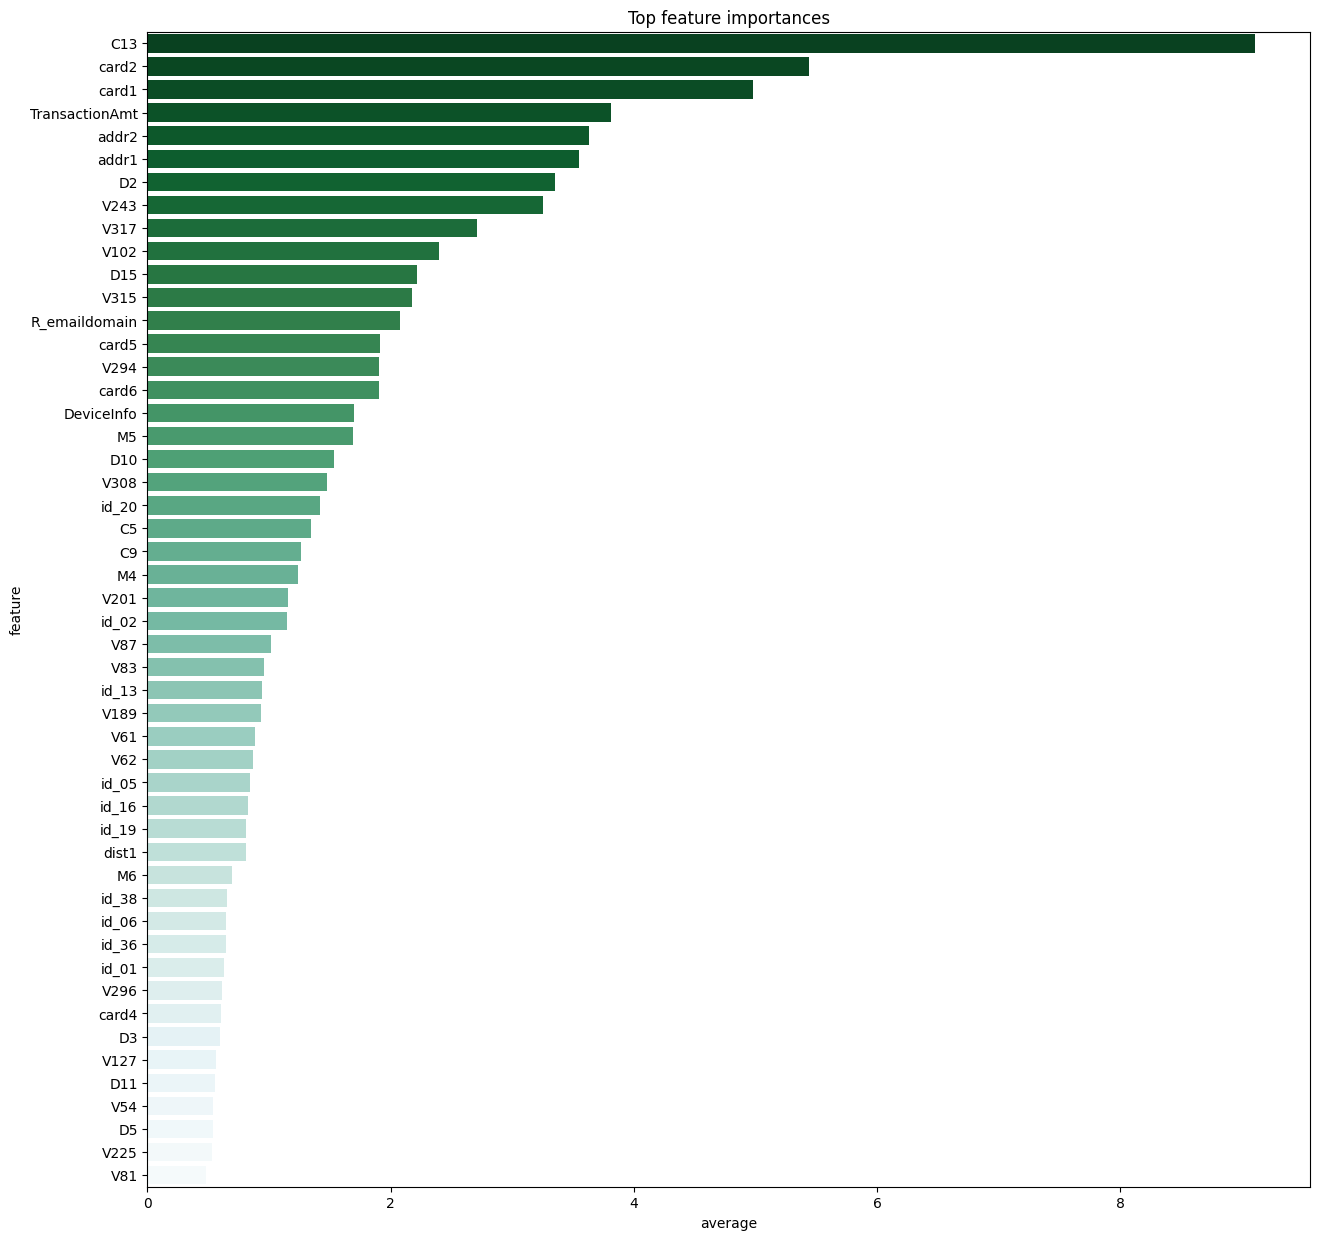

In [180]:
fold_cols = [col for col in feature_importances.columns if col.startswith('fold_')]
feature_importances_cb['average'] = feature_importances_cb[fold_cols].mean(axis=1)
plt.figure(figsize=(15, 15))
sns.barplot(data=feature_importances_cb.sort_values(by='average', ascending=False).head(50), x='average', y='feature', palette="BuGn_r")
plt.title('Top feature importances')
plt.show()

In [182]:
final_pred_cb = np.average(test_preds, axis=0)
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': final_pred_cb})
sub.to_csv('submission_phik+cb.csv', index=False)

In [ ]:
top5lgbm = list(feature_importances.sort_values(by='average', ascending=False).head(5)['feature'])
top5cb = list(feature_importances_cb.sort_values(by='average', ascending=False).head(5)['feature'])
#сформируем табличку с результатами
res=pd.DataFrame({'model' : ['lightgbm', 'catboost'], 'CV' : [np.mean(scores), np.mean(scores_cb)], 'leaderboard' : ['0.91055', '0.73757'], 'TOP-5 feature_importance' : [top5lgbm, top5cb]})
res

,model,CV,leaderboard,TOP-5 feature_importance
0,lightgbm,0.909282,0.91055,"[card1, TransactionAmt, card2, addr1, C13]"
1,catboost,0.677491,0.73757,"[C13, card2, card1, TransactionAmt, addr2]"


*Выводы:*

* качество lightgbm (~0,9) выше, чем у catboost (~0,7)

* ТОП5 важных признаков у 2 моделей почти идентичный, но ранжирование разное

# **Задание 3 (2 балла)**

Попробуйте подойти к задаче как к поиску аномалий.

1) Поищите аномалии (фрод) различными рассмотренными в курсе методами и сделайте прогноз на тестовых данных.

Результатом также будет таблица:
* по строкам - методы поиска аномалий
* по столбцам - качество вашего решения на leaderboard

2) Попробуйте встроить поиск аномалий и их удаление в ML-пайплайн: найдите аномалии и что-нибудь с ними сделайте до обучения моделей (можно удалить их, а можно использовать в качестве дополнительных признаков - попробуйте разные стратегии). Результат проверьте на кросс-валидации и на лидерборде, сделайте выводы.

In [246]:
!pip install pyod


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [247]:
from pyod.models.abod import ABOD
from pyod.models.cblof import CBLOF
from pyod.models.hbos import HBOS
from pyod.models.iforest import IForest
from pyod.models.lof import LOF

from pyod.utils.utility import precision_n_scores
from sklearn.metrics import roc_auc_score

In [250]:
# ваша работа с аномалиями здесь

df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

#удалим малоинформативные столбцы
print(df_train.shape[1])

df_train.drop(['TransactionID'], axis=1, inplace=True)
df_test.drop(['TransactionID'], axis=1, inplace=True)

for col in df_train.columns:
    #удалим признаки, у которых количество уникальных значений 1
    if df_train[col].nunique()<=1:
        df_train.drop(columns=[col], inplace=True)
        df_test.drop(columns=[col], inplace=True)
        continue
    #удалим признаки, где количество пропусков больше 85%
    if col in num_cols:
        if np.isnan(df_train[col]).sum() >= 0.85*df_train.shape[0]:
            df_train.drop(columns=[col], inplace=True)
            df_test.drop(columns=[col], inplace=True)
print(df_train.shape[1])

434
411


In [ ]:
from sklearn.preprocessing import LabelEncoder

outliers_fraction=df_train['isFraud'].sum()/df_train.shape[0]
random_state=1

classifiers = {'Angle-based Outlier Detector (ABOD)': ABOD(
    contamination=outliers_fraction),
    'Cluster-based Local Outlier Factor': CBLOF(
        contamination=outliers_fraction, check_estimator=False,
        random_state=random_state),
    'Histogram-base Outlier Detection (HBOS)': HBOS(
        contamination=outliers_fraction),
    'Isolation Forest': IForest(contamination=outliers_fraction,
                                random_state=random_state),
    'Local Outlier Factor (LOF)': LOF(
        contamination=outliers_fraction),
}

res=pd.DataFrame({'Model': classifiers.keys()})
res['ROC_AUC']=0

for col in tqdm(df_train.columns.drop('isFraud')):
    if df_train[col].dtype == 'O':
        df_train[col] = df_train[col].fillna('unseen_category')
        df_test[col] = df_test[col].fillna('unseen_category')
        
        le = LabelEncoder()
        le.fit(list(df_train[col]) + list(df_test[col]))
        df_train[col] = le.transform(df_train[col])
        df_test[col] = le.transform(df_test[col])
        
        df_train[col] = df_train[col].astype('category')
        df_test[col] = df_test[col].astype('category')

    else:
        df_train[col] = df_train[col].fillna(-1)
        df_test[col] = df_test[col].fillna(-1)

# выделяем фолды
month_length = 3600 * 24 * 30
fold3_idx = df_train[df_train['TransactionDT'].min() + 3 * month_length <= df_train['TransactionDT']].index

# выделяем идентификационный и временной признаки
df_train.drop(['TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionDT'], axis=1, inplace=True)

X_train = df_train.drop(fold3_idx, axis=0)
y_train = X_train['isFraud'].values
X_val = df_train.iloc[fold3_idx]
y_val = X_val['isFraud'].values
X_train = X_train.drop('isFraud', axis=1)
X_val = X_val.drop('isFraud', axis=1)

for clf_name, clf in classifiers.items():
    #обучите алгоритм на X_train_norm
    clf.fit(X_train)
    #test_scores = сделайте предсказание (decision_function) на X_test_norm
    test_scores = clf.decision_function(X_val)
 
    #вычислите roc_auc_score и precision_n_scores для тестовых данных (y_test, test_scores)
    roc = round(roc_auc_score(y_val, np.nan_to_num(test_scores)), ndigits=4)
    prn = round(precision_n_scores(y_val, test_scores), ndigits=4)
    res['ROC_AUC']=roc

    print('{clf_name} ROC:{roc}, precision @ rank n:{prn}, '
          'execution'.format(
        clf_name=clf_name, roc=roc, prn=prn)
    )

    preds=clf.decision_function(df_test)
    sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': preds})
    sub.to_csv('submission_{}.csv'.format(clf_name), index=False)
    


C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\fromnumeric.py:3787: Ru

Angle-based Outlier Detector (ABOD) ROC:0.7457, precision @ rank n:0.0, execution


# **Задание 4 (1 балл)**

Сделайте кластеризацию различными способами. Результаты кластеризации используйте для улучшения ML-решений:

1) Номера кластеров закодируйте (OHE или target-encoding) и добавьте как новые признаки

2) При использовании DBSCAN / HDBSCAN предсказанный шум можно трактовать как найденную аномалию и также добавить ее как новый признак

Проведите различные эксперименты. Проверьте как эти подходы влияют на качество прогнозов по кросс-валидации и на лидерборде, сделайте выводы.

In [ ]:
# ваши эксперименты с кластеризацией здесь
df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

#удалим малоинформативные столбцы
df_train.drop(['TransactionID'], axis=1, inplace=True)
df_test.drop(['TransactionID'], axis=1, inplace=True)

for col in df_train.columns:
    #удалим признаки, у которых количество уникальных значений 1
    if df_train[col].nunique()<=1:
        df_train.drop(columns=[col], inplace=True)
        df_test.drop(columns=[col], inplace=True)
        continue
    #удалим признаки, где количество пропусков больше 85%
    if col in num_cols:
        if np.isnan(df_train[col]).sum() >= 0.85*df_train.shape[0]:
            df_train.drop(columns=[col], inplace=True)
            df_test.drop(columns=[col], inplace=True)

In [ ]:
from sklearn.cluster import KMeans

kmeans_clusterizer = KMeans(n_clusters=3, random_state=1)
kmeans_clusterizer.fit(X)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan_clusterizer = DBSCAN(eps = 0.025)
dbscan_clusterizer.fit(df_train.drop(columns=['isFraud']))

#визуализация кластеров
plt.figure(figsize=(12,8))
palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], 0.5)
                  if col >= 0 else (0.5, 0.5, 0.5) for col in
                  dbscan_clusterizer.labels_]
plt.scatter(df_train.drop(columns=['isFraud']).T[0], df_train.drop(columns=['isFraud']).T[1], c=cluster_colors, **plot_kwds)

In [ ]:
!pip install hdbscan

import hdbscan

hdbscan_clasterizer = hdbscan.HDBSCAN(min_cluster_size=5, gen_min_span_tree=True)
hdbscan_clasterizer.fit(df_train.drop(columns=['isFraud']))

#визуализация кластеров
plt.figure(figsize=(12,8))
palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], sat)
                  if col >= 0 else (0.5, 0.5, 0.5) for col, sat in
                  zip(hdbscan_clasterizer.labels_, hdbscan_clasterizer.probabilities_)]
plt.scatter(df_train.drop(columns=['isFraud']).T[0], df_train.drop(columns=['isFraud']).T[1], c=cluster_colors, **plot_kwds)

## **Задание 5 (1 балл)**

Примените какой-нибудь (один любой) AutoML фреймворк для решения поставленной задачи.

Отправьте AutoML-прогноз на kaggle и посмотрите на качество модели. Сделайте текстовые выводы.

In [ ]:
# ваш AutoML здесь

# **Задание 6 (1 балл)**

Весь курс мы работали в Google Colab. Но всегда должны быть запасные варианты, где Вы будете обучать модели.

Среди вариантов есть:
* ваша локальная машина
* kaggle notebooks
* yandex cloud
и другие.

Кроме привычного Google Colab выберите из списка выше один любой альтернативный вариант и проведите эксперимент:

* Прогоните ваш лучший по качеству по результатам заданий 2-4 ML-пайплайн заново в Google Colab и с помощью библиотек (например, при помощи библиотеки time) замерьте время обучения и отдельно время инференса на тестовых данных

* Прогоните этот пайплайн на выбранном альтернативном сервисе/локальной машине и также замерьте время обучения и инференса.

Текстом напишите выводы: опишите, какое альтернативное место для обучения моделей Вы использовали? Прикрепите прямо в ноутбук скриншот с экраном кода в альтернативном сервисе/на локальной машине. Также в виде таблицы приведите сравнение времени обучения и инференса в колабе и в альтернативном месте. Сделайте выводы.

In [ ]:
# ваши эксперименты здесь

# **Бонус: за Kaggle и стремление к хорошим скорам (2 балла)**

В этом домашнем задании Ваша цель - не просто выполнить шаги выше, но и построить максимально хорошую по качеству модель.

**К 10 вы можете получить до двух дополнительных баллов:**

* За попадание в топ-20% на private leaderboard — +1 дополнительный балл к оценке
* За попадание в топ-5 мест на private leaderboard — + еще один дополнительный балл к оценке (то есть суммарно 2 дополнительных балла)

**ВАЖНО!!!**

Эти баллы ставятся до мягкого дедлайна по соревнованию. После мягкого дедлайна лидерборд не обновляется, и дополнительные баллы не ставятся.

Успехов!

In [ ]:
# не забудьте прикрепить скриншоты лидерборда, пожалуйста